# **Catch22 — Extracción de Características**

## **Setup**

In [1]:
# Librerías
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pycatch22

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "catch22" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"

print("Setup completado")

Setup completado


In [2]:
# Serie total y series de las categorías seleccionadas (regiones y fronteras), a partir del entrenamiento.
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])

series = {
    "Total": entrenamiento.groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - América Del Centro": entrenamiento[entrenamiento["Región dos"] == "América Del Centro"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - América Del Norte": entrenamiento[entrenamiento["Región dos"] == "América Del Norte"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Región - Europa": entrenamiento[entrenamiento["Región dos"] == "Europa"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 01 La Aurora": entrenamiento[entrenamiento["Frontera"] == "01 La Aurora"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 07 Valle Nuevo": entrenamiento[entrenamiento["Frontera"] == "07 Valle Nuevo"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
    "Frontera - 09 San Cristóbal": entrenamiento[entrenamiento["Frontera"] == "09 San Cristóbal"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS"),
}

for nombre, s in series.items():
    print(f"{nombre:30s} obs={s.shape[0]:3d}  inicio={s.index.min().date()}  "
          f"fin={s.index.max().date()}  meses sin registro={s.isna().sum()}")

# América Del Norte y Europa traen 5 meses sin registro (abr-ago 2020, el cierre
# pandémico). Se rellenan con el MÍNIMO de cada serie, que es exactamente el
# criterio que se usó en el Laboratorio 1 al construir estas mismas series. Se
# mantiene ese criterio y no se rellena con cero para no volver a decidir sobre
# los datos: si aquí se usara otra convención, las series dejarían de ser las
# mismas del laboratorio anterior y la comparación perdería sentido. Más adelante
# se verifica que la conclusión del análisis no dependa de esta elección.
series = {nombre: s.fillna(s.min()) for nombre, s in series.items()}
print()
print("Meses rellenados con el mínimo de cada serie:",
      {n: 5 for n in ("Región - América Del Norte", "Región - Europa")})


Total                          obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=0
Región - América Del Centro    obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=0
Región - América Del Norte     obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=5
Región - Europa                obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=5
Frontera - 01 La Aurora        obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=0
Frontera - 07 Valle Nuevo      obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=0
Frontera - 09 San Cristóbal    obs=147  inicio=2009-01-01  fin=2021-03-01  meses sin registro=0

Meses rellenados con el mínimo de cada serie: {'Región - América Del Norte': 5, 'Región - Europa': 5}


## **2.1. ¿Qué es catch22 y por qué es importante?**

catch22 nace de hctsa (*highly comparable time-series analysis*), una librería que calcula más de 7000 características estadísticas para caracterizar una serie de tiempo. Ese conjunto es masivo, lento de calcular y muy redundante (muchas características miden esencialmente lo mismo). catch22 es el resultado de un proceso de selección sobre ese banco de más de 7000 features: se evaluó qué tan bien cada una distinguía entre series de un banco de datos de clasificación muy diverso (miles de series de dominios distintos), y de ahí se escogió un subconjunto de 22 características que, en conjunto, (1) tienen un buen desempeño individual para discriminar entre series, (2) son lo más independientes posible entre sí (poca redundancia), y (3) se pueden calcular en tiempo lineal, de forma rápida y con una implementación ligera en C.

Las 22 características cubren distintas facetas de la dinámica de una serie: forma de la distribución, estructura de autocorrelación, linealidad/no linealidad, entropía y forecastability, y propiedades de escala/fluctuación, entre otras. Es importante porque permite pasar de una serie de tiempo completa a un vector pequeño y comparable de 22 números que resume su comportamiento, algo muy útil para comparar, agrupar (clustering) o clasificar muchas series entre sí de forma barata, sin tener que correr el banco completo de hctsa ni ajustar un modelo completo para cada serie.

## **2.2. Extracción de las 22 características para cada serie**

In [3]:
# catch22 para cada una de las series (serie total + regiones + fronteras seleccionadas).
resultados = {}
for nombre, s in series.items():
    salida = pycatch22.catch22_all(list(s.values), catch24=False)
    resultados[nombre] = dict(zip(salida["names"], salida["values"]))

tabla_catch22 = pd.DataFrame(resultados)
tabla_catch22

,Total,Región - América Del Centro,Región - América Del Norte,Región - Europa,Frontera - 01 La Aurora,Frontera - 07 Valle Nuevo,Frontera - 09 San Cristóbal
DN_HistogramMode_5,0.174564,-0.601979,-0.341361,0.478700,-0.335017,0.286514,-0.232536
DN_HistogramMode_10,-0.580843,-0.356208,-0.102668,0.259610,-0.069026,0.058509,-0.934744
CO_f1ecac,8.105554,8.532877,4.695946,3.777726,6.237583,8.284985,5.461214
CO_FirstMin_ac,10.000000,10.000000,2.000000,7.000000,10.000000,11.000000,7.000000
CO_HistogramAMI_even_2_5,0.467207,0.490904,0.224773,0.314402,0.284910,0.341134,0.340735
CO_trev_1_num,-0.067552,-0.042162,-0.132087,-0.099285,-0.097577,-0.042117,-0.015131
MD_hrv_classic_pnn40,0.917808,0.917808,0.938356,0.938356,0.931507,0.924658,0.876712
SB_BinaryStats_mean_longstretch1,30.000000,42.000000,12.000000,8.000000,42.000000,38.000000,29.000000
SB_TransitionMatrix_3ac_sumdiagcov,0.046296,0.080000,0.025510,0.030000,0.063333,0.046296,0.062500
PD_PeriodicityWang_th0_01,11.000000,11.000000,3.000000,11.000000,11.000000,7.000000,11.000000


## **2.3. Matriz serie × característica**

`tabla_catch22` quedó con las características en filas y las series en columnas (conveniente para inspección). Para el análisis comparativo se necesita la matriz en el formato estándar: una fila por serie, una columna por característica de catch22.

In [4]:
# Matriz serie x característica (filas=series, columnas=características catch22).
matriz = tabla_catch22.T
matriz.index.name = "Serie"
print(f"matriz.shape = {matriz.shape}  (series x características)")
matriz

matriz.shape = (7, 22)  (series x características)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,0.174564,-0.580843,8.105554,10.0,0.467207,-0.067552,0.917808,30.0,0.046296,11.0,...,0.045455,0.625850,0.891156,0.816813,6.0,1.833320,0.850,0.75,0.147262,0.613916
Región - América Del Centro,-0.601979,-0.356208,8.532877,10.0,0.490904,-0.042162,0.917808,42.0,0.080000,11.0,...,0.038462,0.639456,0.891156,0.821167,6.0,1.855498,0.850,0.75,0.147262,0.603843
Región - América Del Norte,-0.341361,-0.102668,4.695946,2.0,0.224773,-0.132087,0.938356,12.0,0.025510,3.0,...,0.100000,0.312925,0.891156,0.622429,5.0,2.123190,0.850,0.70,0.269981,0.872965
Región - Europa,0.478700,0.259610,3.777726,7.0,0.314402,-0.099285,0.938356,8.0,0.030000,11.0,...,0.071429,0.374150,0.904762,0.705047,6.0,2.105974,0.150,0.70,0.319068,0.815444
Frontera - 01 La Aurora,-0.335017,-0.069026,6.237583,10.0,0.284910,-0.097577,0.931507,42.0,0.063333,11.0,...,0.142857,0.605442,0.891156,0.790485,5.0,1.955550,0.150,0.80,0.171806,0.687132
Frontera - 07 Valle Nuevo,0.286514,0.058509,8.284985,11.0,0.341134,-0.042117,0.924658,38.0,0.046296,7.0,...,0.045455,0.591837,0.571429,0.804835,6.0,1.839140,0.825,0.65,0.147262,0.616151
Frontera - 09 San Cristóbal,-0.232536,-0.934744,5.461214,7.0,0.340735,-0.015131,0.876712,29.0,0.062500,11.0,...,0.033333,0.544218,-0.278912,0.783114,5.0,1.764556,0.150,0.80,0.171806,0.711351


## **2.4. Estandarización**

Las 22 características viven en escalas muy distintas (conteos de rezagos, proporciones entre 0 y 1, longitudes de racha, etc.), así que se estandariza cada columna (media 0, desviación 1) antes de PCA, clustering o distancias — de lo contrario las características con magnitudes más grandes dominarían esos análisis.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
matriz_z = pd.DataFrame(
    scaler.fit_transform(matriz),
    index=matriz.index,
    columns=matriz.columns,
)
matriz_z

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,0.698884,-0.885141,0.944975,0.640464,1.300631,0.086955,-0.149256,0.100335,-0.237472,0.588348,...,-0.608505,0.812090,0.518005,0.786038,0.866025,-0.704667,0.883979,0.277350,-0.763763,-0.909167
Región - América Del Centro,-1.419834,-0.290474,1.187753,0.640464,1.568179,0.757472,-0.149256,1.036795,1.638682,0.588348,...,-0.796071,0.924657,0.518005,0.850126,0.866025,-0.534792,0.883979,0.277350,-0.763763,-1.011997
Región - América Del Norte,-0.708764,0.380711,-0.992153,-2.118458,-1.436550,-1.617339,0.895533,-1.304355,-1.394553,-2.157277,...,0.854510,-1.776950,0.518005,-2.075247,-1.154701,1.515612,0.883979,-0.693375,1.145644,1.735451
Región - Europa,1.528687,1.339754,-1.513828,-0.394132,-0.424602,-0.751083,0.895533,-1.616508,-1.144624,0.588348,...,0.088169,-1.270399,0.551424,-0.859137,0.866025,1.383746,-1.154373,-0.693375,1.909407,1.148220
Frontera - 01 La Aurora,-0.691456,0.469770,-0.116290,0.640464,-0.757583,-0.705983,0.547270,1.036795,0.710914,0.588348,...,2.004022,0.643240,0.518005,0.398491,-1.154701,0.231562,-1.154373,1.248075,-0.381881,-0.161707
Frontera - 07 Valle Nuevo,1.004328,0.807387,1.046916,0.985329,-0.122786,0.758653,0.199007,0.724642,-0.237472,-0.784465,...,-0.608505,0.530673,-0.267357,0.609730,0.866025,-0.660090,0.811181,-1.664101,-0.763763,-0.886347
Frontera - 09 San Cristóbal,-0.411845,-1.822007,-0.557375,-0.394132,-0.127290,1.471325,-2.238834,0.022297,0.664525,0.588348,...,-0.933620,0.136688,-2.356085,0.289997,-1.154701,-1.231369,-1.154373,1.248075,-0.381881,0.085547


## **2.5. Análisis sobre la matriz catch22**

### PCA

Cabe mencionar antes de empezar que se trabaja con 7 series y 22 características, es decir con más variables que observaciones, de tal forma que estos análisis se deben leer como exploratorios: sirven para ver qué series se parecen entre sí, pero no soportan afirmaciones finas sobre una característica individual.


Varianza explicada por componente: [0.491 0.195]
Varianza explicada acumulada: [0.491 0.686]


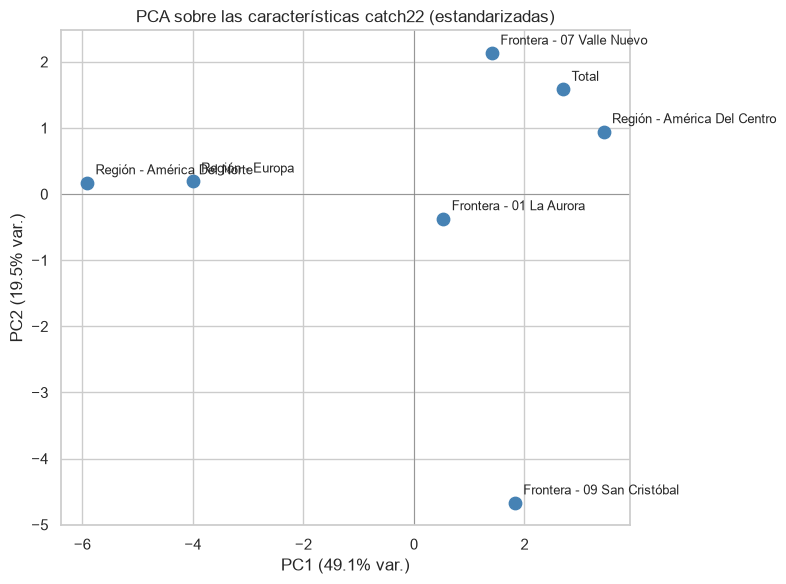

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
componentes = pca.fit_transform(matriz_z)
pca_df = pd.DataFrame(componentes, index=matriz_z.index, columns=["PC1", "PC2"])

print("Varianza explicada por componente:", np.round(pca.explained_variance_ratio_, 3))
print("Varianza explicada acumulada:", np.round(pca.explained_variance_ratio_.cumsum(), 3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=80, color="steelblue")
for nombre, fila in pca_df.iterrows():
    ax.annotate(nombre, (fila["PC1"], fila["PC2"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title("PCA sobre las características catch22 (estandarizadas)")
plt.tight_layout()
plt.show()

### Clustering

Con solo 7 series, un clustering jerárquico (linkage completo, distancia euclidiana) es más informativo que fijar un número de clusters a priori: el dendrograma muestra a qué distancia se van uniendo las series.

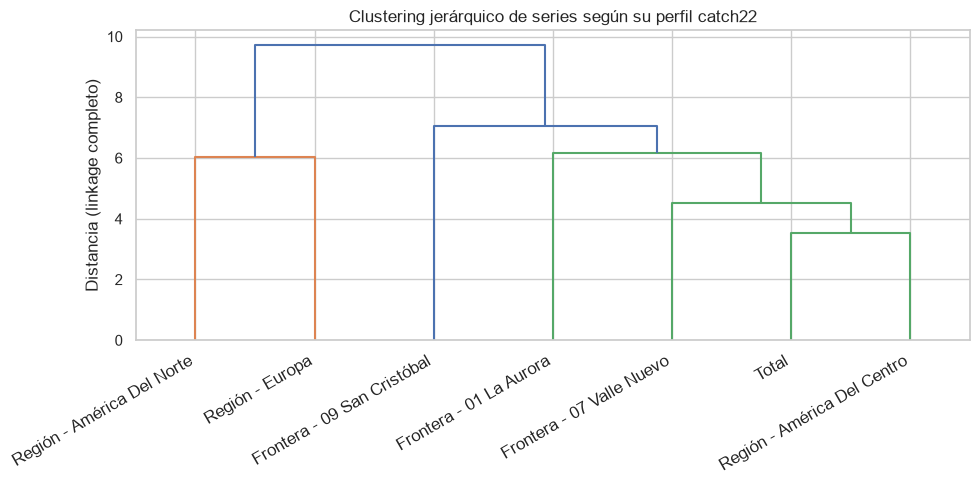

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

enlace = linkage(matriz_z.values, method="complete", metric="euclidean")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(enlace, labels=matriz_z.index.tolist(), ax=ax, color_threshold=0.7 * max(enlace[:, 2]))
ax.set_title("Clustering jerárquico de series según su perfil catch22")
ax.set_ylabel("Distancia (linkage completo)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Heatmap de características

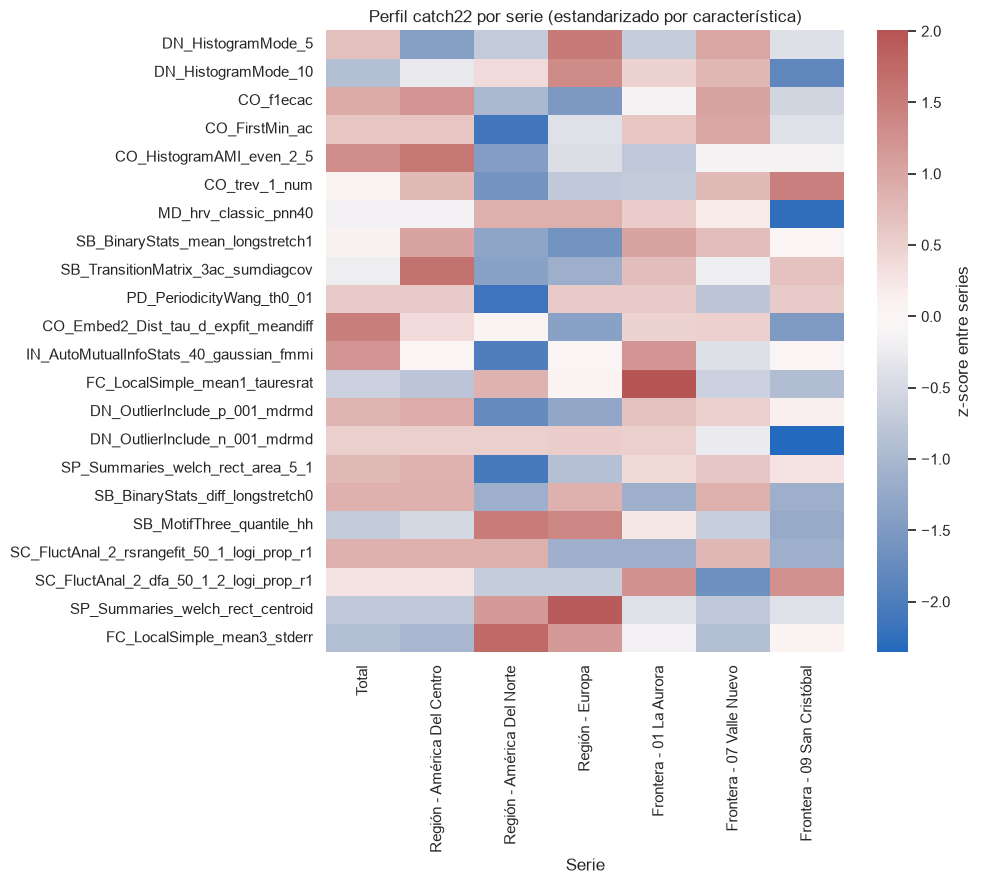

In [8]:
# Heatmap de las características estandarizadas (matriz_z), para comparar el perfil de cada serie.
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(matriz_z.T, cmap="vlag", center=0, ax=ax, cbar_kws={"label": "z-score entre series"})
ax.set_title("Perfil catch22 por serie (estandarizado por característica)")
plt.tight_layout()
plt.show()

### Matriz de correlaciones entre características

Esta matriz es la que más hay que tomar con pinzas de todo el análisis, ya que la correlación entre cada par de características se estima con solo 7 puntos. Con esa cantidad la matriz tiene rango máximo 6 y muchos coeficientes salen cercanos a ±1 por construcción y no porque exista una asociación real, de tal forma que sirve para detectar bloques de características que se mueven juntas, pero no para interpretar un coeficiente puntual.


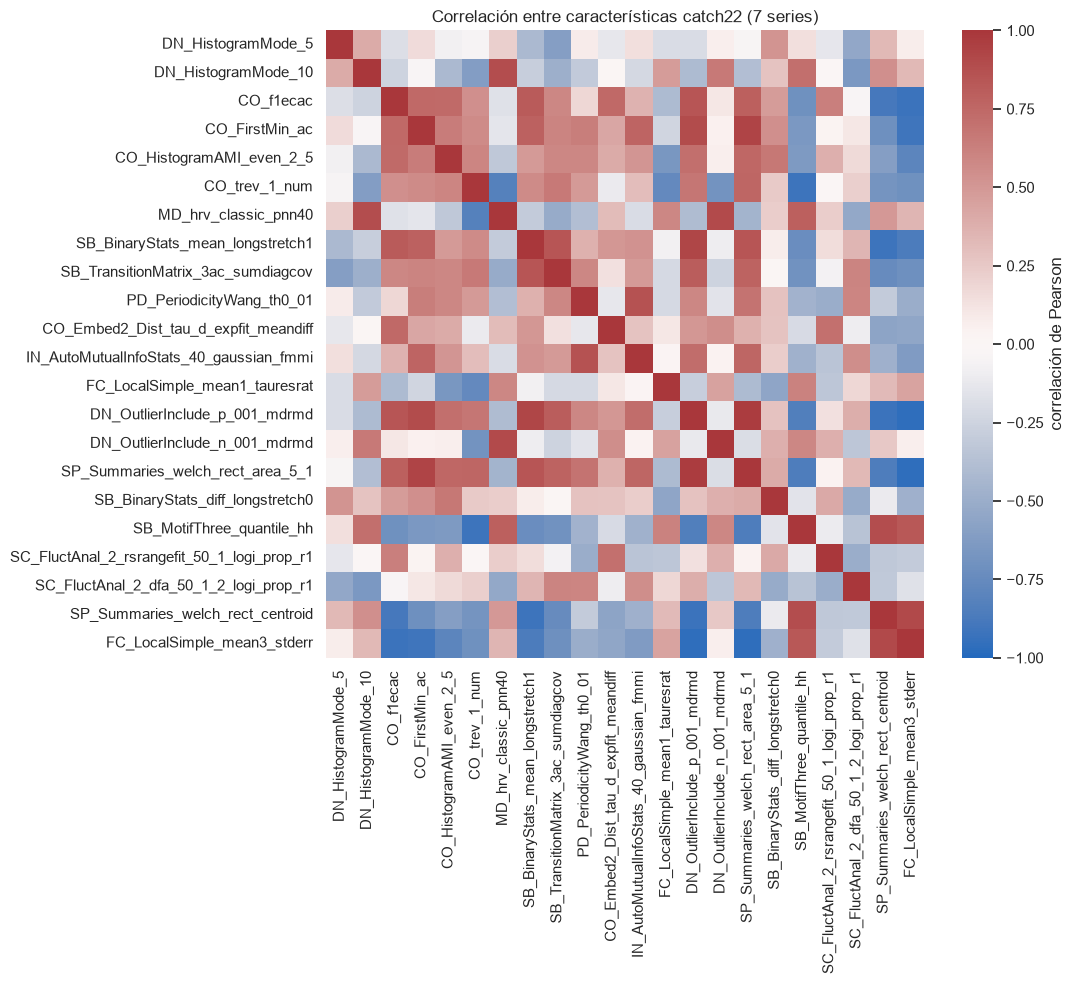

In [9]:
correlacion_features = matriz_z.corr()

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(correlacion_features, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "correlación de Pearson"})
ax.set_title("Correlación entre características catch22 (7 series)")
plt.tight_layout()
plt.show()

### Mapa de distancias entre series

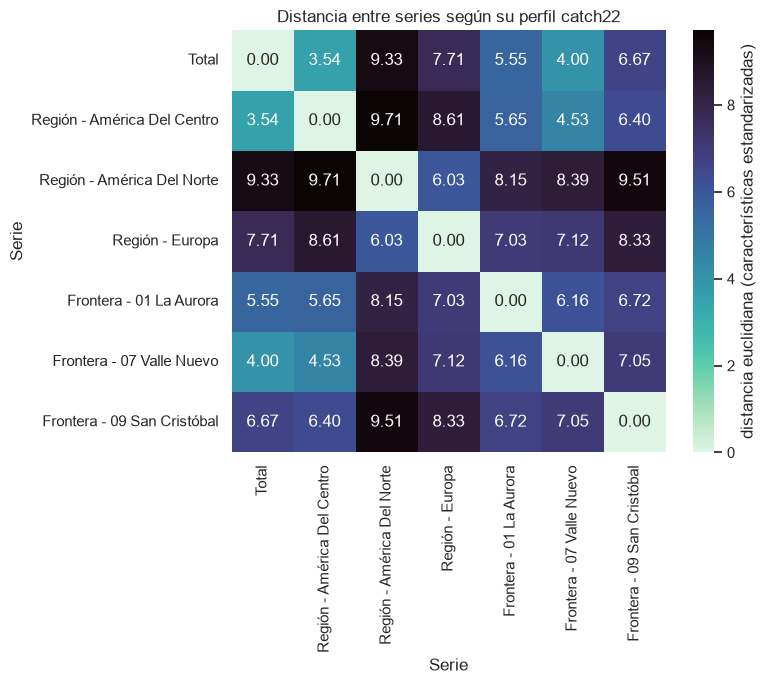

In [10]:
from scipy.spatial.distance import pdist, squareform

distancias = pd.DataFrame(
    squareform(pdist(matriz_z.values, metric="euclidean")),
    index=matriz_z.index,
    columns=matriz_z.index,
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(distancias, cmap="mako_r", annot=True, fmt=".2f", ax=ax,
            cbar_kws={"label": "distancia euclidiana (características estandarizadas)"})
ax.set_title("Distancia entre series según su perfil catch22")
plt.tight_layout()
plt.show()

### Verificación de robustez del relleno

Antes de interpretar los resultados conviene descartar que el agrupamiento sea un artefacto de cómo
se rellenaron los cinco meses sin registro de América Del Norte y Europa. Es una preocupación
razonable, ya que son justamente esas dos series las que se separan del resto, de tal forma que si
el relleno fuera el que produce la separación, toda la interpretación quedaría sin piso.

Para descartarlo se repite el análisis completo con la otra convención posible, que es rellenar esos
meses con cero, y se comparan los grupos y las distancias que resultan.


In [11]:
# Se repite el analisis con relleno en cero y se comparan los resultados.
from scipy.cluster.hierarchy import fcluster

# La matriz con el relleno del Lab 1 ya esta calculada (matriz_z). Se reconstruye
# la alternativa desde el crudo, rellenando con cero.
series_cero = {}
for nombre, (col, val) in {
    "Total": (None, None),
    "Región - América Del Centro": ("Región dos", "América Del Centro"),
    "Región - América Del Norte": ("Región dos", "América Del Norte"),
    "Región - Europa": ("Región dos", "Europa"),
    "Frontera - 01 La Aurora": ("Frontera", "01 La Aurora"),
    "Frontera - 07 Valle Nuevo": ("Frontera", "07 Valle Nuevo"),
    "Frontera - 09 San Cristóbal": ("Frontera", "09 San Cristóbal"),
}.items():
    d = entrenamiento if col is None else entrenamiento[entrenamiento[col] == val]
    series_cero[nombre] = d.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0.0)

m_cero = pd.DataFrame({n: dict(zip(*[pycatch22.catch22_all(list(s.values), catch24=False)[k]
                                     for k in ("names", "values")]))
                       for n, s in series_cero.items()}).T
z_cero = pd.DataFrame(StandardScaler().fit_transform(m_cero), index=m_cero.index, columns=m_cero.columns)

comparacion_relleno = pd.DataFrame({
    "grupo (relleno mínimo, Lab 1)": fcluster(linkage(matriz_z.values, method="complete"), 2, "maxclust"),
    "grupo (relleno cero)": fcluster(linkage(z_cero.values, method="complete"), 2, "maxclust"),
}, index=matriz_z.index)

d_min = squareform(pdist(matriz_z.values))
d_cero = squareform(pdist(z_cero.values))
comparacion_relleno["dist. al resto (mínimo)"] = d_min.sum(axis=1).round(2)
comparacion_relleno["dist. al resto (cero)"] = d_cero.sum(axis=1).round(2)

display(comparacion_relleno)
print(f"Los grupos coinciden en las 7 series: "
      f"{(comparacion_relleno.iloc[:, 0] == comparacion_relleno.iloc[:, 1]).all()}")
print(f"Diferencia máxima entre las dos matrices de distancias: "
      f"{np.abs(d_min - d_cero).max():.2f}")


,"grupo (relleno mínimo, Lab 1)",grupo (relleno cero),dist. al resto (mínimo),dist. al resto (cero)
Serie,,,,
Total,2,2,36.80,36.92
Región - América Del Centro,2,2,38.45,38.53
Región - América Del Norte,1,1,51.12,50.99
Región - Europa,1,1,44.81,44.78
Frontera - 01 La Aurora,2,2,39.25,39.30
Frontera - 07 Valle Nuevo,2,2,37.25,37.36
Frontera - 09 San Cristóbal,2,2,44.68,44.55


Los grupos coinciden en las 7 series: True
Diferencia máxima entre las dos matrices de distancias: 0.09


### Métricas del análisis exploratorio del Laboratorio 1

Para poder contrastar lo que dice catch22 contra lo que ya se había observado, se recalculan las
cuatro medidas comparativas del laboratorio anterior sobre estas mismas siete series: la
autocorrelación en el mes 12 como medida de estacionalidad, el porcentaje de crecimiento entre 2009
y 2019 como medida de tendencia, el coeficiente de variación como medida de volatilidad y el
porcentaje de caída de 2019 a 2020 como medida del impacto de la pandemia. Cabe mencionar que las
tres primeras se calculan sobre el tramo previo a la pandemia, tal como se hizo en el Laboratorio 1,
para que el desplome de 2020 no distorsione el resultado.


In [12]:
# Mismas cuatro medidas comparativas del Laboratorio 1, para contrastarlas contra catch22.
from statsmodels.tsa.stattools import acf

def metricas_eda(x):
    pre = x[(x.index >= "2009-01-01") & (x.index < "2020-01-01")]
    anual = pre.groupby(pre.index.year).sum()
    return {
        "ACF_mes_12": round(float(acf(pre.diff().dropna(), nlags=12)[12]), 2),
        "crecimiento_%": round(float(anual.loc[2019] / anual.loc[2009] - 1) * 100),
        "CV": round(float(pre.std() / pre.mean()), 2),
        "caida_pandemia_%": round(float(1 - x[x.index.year == 2020].min()
                                        / x[x.index.year == 2019].mean()) * 100, 1),
    }

eda_lab1 = pd.DataFrame({n: metricas_eda(s) for n, s in series.items()}).T
eda_lab1["PC1"] = pca_df["PC1"].round(2)
eda_lab1["PC2"] = pca_df["PC2"].round(2)
eda_lab1


,ACF_mes_12,crecimiento_%,CV,caida_pandemia_%,PC1,PC2
Total,0.59,120.0,0.31,97.2,2.70,1.59
Región - América Del Centro,0.55,155.0,0.36,96.4,3.43,0.95
Región - América Del Norte,0.79,45.0,0.24,97.7,-5.91,0.17
Región - Europa,0.80,26.0,0.25,99.8,-4.00,0.20
Frontera - 01 La Aurora,0.77,59.0,0.22,99.6,0.53,-0.37
Frontera - 07 Valle Nuevo,0.49,152.0,0.40,99.9,1.41,2.13
Frontera - 09 San Cristóbal,0.35,238.0,0.52,100.0,1.83,-4.67


## **2.6. Análisis e interpretación**

Antes de responder conviene dejar clara una limitación que condiciona todo lo que sigue. El análisis
se hace sobre **7 series y 22 características**, es decir hay más variables que observaciones, de tal
forma que el PCA y sobre todo la matriz de correlaciones entre características se apoyan en muy poca
información: con 7 puntos, la matriz de correlaciones tiene rango máximo 6 y buena parte de sus
valores quedan cerca de ±1 por construcción y no porque las características estén realmente
asociadas. Bajo esta idea, las conclusiones que siguen se sostienen en lo que es estable —los
agrupamientos, las distancias y el orden de las series sobre los componentes— y no en el valor
puntual de una correlación entre dos características.

---

## **2.7. ¿Cuáles series presentan comportamientos más similares?**

El par más parecido de todos es **Total y Región - América Del Centro**, con una distancia euclidiana
de 3.54, la menor de las 21 posibles. Esto tiene sentido y era esperable, ya que América Del Centro
concentra alrededor del 73% de los viajeros del período de entrenamiento, de tal forma que su
dinámica mensual es prácticamente la que arrastra a la serie Total.

Asimismo, se identifica un bloque de cinco series que se comportan de forma parecida entre sí: Total,
América Del Centro y las tres fronteras. En el PCA todas quedan del mismo lado del plano, con PC1
positivo entre 0.53 y 3.43, y en el dendrograma se van uniendo a distancias moderadas.

Por otro lado, **América Del Norte y Europa** son las más parecidas entre sí dentro de su propio
bloque, con una distancia de 6.03, pero es un parecido de otra naturaleza, ya que lo que realmente
las define es lo lejos que están del resto: entre 7.03 y 9.71 de las otras cinco, que son las mayores
distancias de todo el análisis. Es decir, no se parecen tanto por ser iguales entre ellas como por
ser ambas distintas a todas las demás.

---

## **2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**

Revisando los pesos (*loadings*) de los dos primeros componentes, que juntos explican cerca del 69%
de la varianza, las características que más pesan son las siguientes.

**PC1 (49.1% de la varianza)** — recoge la forma del espectro y qué tan predecible es la serie:

| Característica | Qué mide |
|---|---|
| `SP_Summaries_welch_rect_area_5_1` | Cuánta energía se concentra en las frecuencias bajas |
| `DN_OutlierInclude_p_001_mdrmd` | Cómo aparecen los valores atípicos altos |
| `FC_LocalSimple_mean3_stderr` | Qué tan predecible es la serie con un promedio móvil simple |
| `SB_MotifThree_quantile_hh` | Entropía de los patrones de la serie simbolizada |
| `SP_Summaries_welch_rect_centroid` | En qué frecuencia se centra la energía del espectro |
| `SB_BinaryStats_mean_longstretch1` | Racha más larga por encima de la media |

**PC2 (19.5% de la varianza)** — separa por valores atípicos bajos y por el patrón de fluctuación:
`DN_OutlierInclude_n_001_mdrmd`, `MD_hrv_classic_pnn40`, `CO_Embed2_Dist_tau_d_expfit_meandiff`,
`SB_BinaryStats_diff_longstretch0` y las dos de `SC_FluctAnal`.

En resumen, lo que más separa a estas siete series no es el nivel de viajeros, ya que catch22
z-normaliza cada serie antes de calcular las características y por lo tanto la escala queda fuera del
análisis, sino **cómo se reparte la energía de la serie entre su tendencia de largo plazo y su ciclo
anual**, junto con qué tan predecible resulta mes a mes.

---

## **2.9. ¿Existen grupos naturales de series? ¿Qué tienen en común?**

Sí, el dendrograma y el PCA coinciden en dos grupos, y lo que los separa es el balance entre
tendencia y estacionalidad.

**Grupo A — series dominadas por la tendencia** (Total, América Del Centro y las tres fronteras).
Tienen rachas largas por encima de su media, entre 29 y 42 meses, lo cual es la firma de una serie
que crece de forma sostenida: una vez que supera su propio promedio ya no vuelve a bajar de él. Su
energía espectral se concentra en frecuencias bajas, con `welch_rect_centroid` entre 0.147 y 0.172 y
`welch_rect_area_5_1` entre 0.783 y 0.821, que es lo que corresponde a una serie cuya mayor fuente de
variación es el crecimiento de largo plazo.

**Grupo B — series dominadas por el ciclo anual** (América Del Norte y Europa). Aquí las rachas por
encima de la media son mucho más cortas, de apenas 12 y 8 meses, es decir la serie cruza su promedio
una y otra vez en lugar de instalarse por encima, que es lo que ocurre cuando el movimiento
predominante es el ciclo estacional y no el crecimiento. Consistente con eso, su energía se desplaza
a frecuencias más altas, con `welch_rect_centroid` de 0.270 y 0.319 frente al máximo de 0.172 del
Grupo A.

Cabe mencionar que esta lectura se confirma con las medidas del Laboratorio 1: las dos series del
Grupo B son las de mayor estacionalidad de las siete, con una autocorrelación de 0.79 y 0.80 en el
mes 12 frente al 0.77 de la más estacional del Grupo A, y a la vez las de menor crecimiento entre
2009 y 2019, con 45% y 26% frente al 59% de la que menos creció del Grupo A. De tal forma que ambas
medidas separan a los grupos de forma limpia y en la dirección que anticipan las características de
catch22.

---

## **2.10. ¿Las series de una misma categoría tienden a agruparse?**

No, y este resultado es más fuerte de lo que parece a primera vista. Las categorías disponibles en
esta selección son región y frontera, ya que no se construyeron series por país, por vía de ingreso
ni por tipo de viajero.

En el caso de las **regiones**, no se agrupan en absoluto: América Del Centro queda en el Grupo A
mientras que América Del Norte y Europa forman el Grupo B, y de hecho la distancia entre Centro y
Norte, de 9.71, es la mayor de todo el análisis.

En el caso de las **fronteras**, tampoco se agrupan entre sí, aunque las tres caigan del mismo lado
del plano. Al mirar las distancias se ve que cada frontera está **más cerca de la serie Total que de
cualquiera de las otras dos fronteras**: La Aurora queda a 5.55 del Total pero a 6.16 y 6.72 de sus
dos pares, Valle Nuevo a 4.00 del Total pero a 6.16 y 7.05, y San Cristóbal a 6.67 del Total pero a
6.72 y 7.05. Es decir, compartir la categoría "frontera" no las hace parecidas.

Bajo esta idea, la conclusión es que el agrupamiento no sigue la categoría administrativa sino el
comportamiento dinámico de cada serie, concretamente si la domina su tendencia o su ciclo anual.

---

## **2.11. Series con el comportamiento más atípico**

Hay dos tipos de atipicidad, y conviene separarlos porque aparecen en componentes distintos.

Sobre **PC1**, la más atípica es **América Del Norte**, con un valor de −5.91, seguida de **Europa**
con −4.00, muy lejos del resto que va de 0.53 a 3.43. La justificación es la ya discutida: son las
dos series donde el ciclo anual domina sobre una tendencia débil, y por eso su perfil espectral y sus
rachas se apartan tanto del resto. Adicional, cabe mencionar que La Aurora es el caso de transición,
ya que con un PC1 de 0.53 es la más cercana a la frontera entre grupos, lo cual concuerda con que en
el Laboratorio 1 fue la de mayor estacionalidad de las fronteras (0.77) y la de menor crecimiento
(59%), es decir, comparte rasgos con el Grupo B pero no los suficientes para cruzar.

Sobre **PC2**, la atípica es **San Cristóbal**, con −4.67 frente al resto que queda entre −0.37 y
2.13. Esto se explica porque es la única serie con `DN_OutlierInclude_n_001_mdrmd` negativo, en
−0.279 frente a valores de 0.571 a 0.905 en las demás, es decir su patrón de aparición de valores
atípicos bajos es distinto al de todas las otras. Diría que esto concuerda con lo que ya mostraba el
Laboratorio 1, donde San Cristóbal resultó la frontera más volátil, con un coeficiente de variación
de 0.52, y la de mayor crecimiento porcentual, con 238%, ambas las cifras más altas de las siete
series.

---

## **2.12. Comparación con el análisis exploratorio del Laboratorio 1**

Contrastando los agrupamientos contra las cuatro medidas del laboratorio anterior, el resultado es
consistente en tres de los cinco aspectos que se piden, y en los otros dos el contraste resulta
incluso más informativo que la coincidencia.

**Tendencia — consistente.** El crecimiento entre 2009 y 2019 separa los grupos de forma limpia: el
Grupo A va de 59% a 238% y el Grupo B se queda en 45% y 26%. Esto es precisamente lo que anticipaban
las rachas y el espectro.

**Estacionalidad — consistente, y es el factor decisivo.** La autocorrelación en el mes 12 también
separa los grupos sin traslape: 0.79 y 0.80 en el Grupo B frente a un máximo de 0.77 en el Grupo A.

**Volatilidad — no coincide, y eso es un hallazgo.** El coeficiente de variación no separa los
grupos, ya que el Grupo B queda en 0.24 y 0.25, valores que caen dentro del rango del Grupo A, que va
de 0.22 a 0.52. De tal forma que la volatilidad, que en el análisis exploratorio parecía un rasgo
distintivo, no es lo que catch22 usa para separar estas series.

**Impacto de la pandemia — no coincide, y es lo más interesante.** Todas las series cayeron entre
96.4% y 100% en 2020, es decir el golpe fue prácticamente total y parejo en las siete. Por lo tanto
la pandemia, que es el evento más visible en cualquier gráfico de estas series, **no puede ser lo que
las separa**, ya que las afectó a todas por igual. Esto es importante porque es la explicación
intuitiva a la que uno llegaría mirando las gráficas, y las cifras la descartan.

**Autocorrelación — consistente, con un matiz que hay que explicar.** Las características de catch22
relacionadas con la ACF de corto plazo, como `CO_f1ecac`, son más bajas en el Grupo B, con 4.70 y
3.78 frente a 5.46 a 8.53 en el resto, lo cual indica que su autocorrelación decae más rápido en los
primeros rezagos. Cabe aclarar que esto no contradice el hecho de que sean las más estacionales, ya
que son cosas distintas: `CO_f1ecac` mide qué tan rápido se pierde la memoria de corto plazo,
mientras que la estacionalidad se manifiesta en el rezago 12. Una serie sin tendencia fuerte pierde
rápido la correlación con el mes anterior y aun así repite fielmente su patrón cada año, que es
exactamente el caso de América Del Norte y Europa.

---

## **2.13. Descubrimientos que no eran evidentes en el análisis exploratorio tradicional**

**Primero, la pandemia no es lo que distingue a estas series.** Es el evento más llamativo en
cualquier gráfico y la explicación a la que uno llegaría de forma natural, pero al medirlo resulta
que las siete cayeron entre 96.4% y 100%, de tal forma que no puede ser el factor que las separa. Lo
que sí las separa es algo mucho menos visible a simple vista, que es el balance entre cuánto de su
movimiento viene de la tendencia y cuánto del ciclo anual.

**Segundo, las tres fronteras no se parecen entre sí.** En el análisis tradicional se las trata como
un bloque por pertenecer a la misma categoría, y de hecho en el Laboratorio 1 se compararon entre
ellas como si fueran comparables. Sin embargo, al medir la distancia entre sus perfiles catch22
resulta que cada una está más cerca de la serie Total que de sus dos pares. Es decir, la categoría
administrativa no captura el comportamiento.

**Tercero, San Cristóbal tiene una firma propia en los valores atípicos bajos.** Es la única de las
siete con `DN_OutlierInclude_n_001_mdrmd` negativo, y esa anomalía la aísla en el segundo componente
con un valor de −4.67 muy lejos del resto. Es un rasgo puntual y sutil que no se distingue mirando la
tendencia, la estacionalidad ni la descomposición de la serie.

**Cuarto, La Aurora es un caso de transición y no un miembro pleno de su grupo.** Con un PC1 de 0.53
es la serie más cercana al límite entre los dos grupos, lo cual concuerda con que sea la frontera más
estacional y la de menor crecimiento. Esto no se aprecia en el análisis tradicional, donde La Aurora
simplemente aparece como la frontera de mayor volumen, mientras que catch22 la ubica en la posición
intermedia que realmente le corresponde por su dinámica.


---

## **2.14. Modelo LSTM con las características de catch22**

El enunciado pide hacer un nuevo modelo LSTM "con las características generadas por catch22" y
compararlo contra el mejor LSTM de una de las series estudiadas. En este caso se trabaja sobre
**01 La Aurora**, que es una de las dos series que se modelaron en el ejercicio 1.

Conviene aclarar primero qué puede significar esto, ya que la lectura literal no es viable. catch22
produce **22 números por serie**, de tal forma que para La Aurora eso sería una sola fila de 22
valores, y con una sola fila no se puede entrenar una red: no hay secuencia que recorrer ni nada que
predecir. Bajo esta idea, la interpretación que sí tiene sentido es calcular catch22 sobre una
**ventana móvil** en lugar de sobre la serie completa, es decir, en cada mes calcularle las 22
características a los últimos 36 meses. Eso convierte 22 números fijos en 22 series de tiempo
nuevas, que describen no el valor de la serie sino cómo se ha venido comportando últimamente.

Con eso la red deja de ser univariada. Hoy recibe únicamente los últimos 12 valores de viajeros; con
las características recibe además, en cada paso, un resumen de qué tan estacional, qué tan
predecible y qué tan concentrado espectralmente ha estado el comportamiento reciente.

**Cómo se construye, y los tres cuidados que importan.**

Primero, la **causalidad**: las características del mes *t* se calculan únicamente con los 36 meses
anteriores a *t*, sin incluirlo. Si se calcularan con una ventana centrada o incluyendo el mes en
curso habría fuga de información y las métricas dejarían de significar algo.

Segundo, **cuántas características entran**. Meter las 22 en un entrenamiento que solo tiene 99
muestras es pedirle a la red que aprenda demasiado con muy poco, así que se reducen con PCA a 3
componentes, ajustando el PCA solo con el tramo de entrenamiento. Adicional, esto conecta de forma
natural con el análisis del 2.5, donde ya se había visto que dos o tres componentes recogen la mayor
parte de la información de las 22 características.

Tercero, y es el que más pesa, el **pronóstico recursivo**. Para predecir 63 meses realimentando sus
propias predicciones, la red necesita en cada paso las características de una ventana que ya incluye
lo que ella misma predijo. De tal forma que el error se acumula por dos vías en lugar de una: la
predicción se desvía, esa desviación entra al cálculo de las características, y las características
desviadas empeoran la siguiente predicción.

**Cómo se hace justa la comparación.** Se deja exactamente la misma arquitectura ganadora del
ejercicio 1 para esta serie, es decir una LSTM simple de una capa con 16 unidades, ventana de 12
meses y tasa de aprendizaje de 0.001, de modo que lo único que cambia es qué entra a la red.
Asimismo, se agrega un tercer modelo de control: el mismo modelo univariado pero entrenado sobre el
**mismo rango temporal reducido**, ya que al necesitar 36 meses previos para calcular las
características se pierden las primeras observaciones y el modelo con catch22 entrena con 99
muestras en lugar de 135. Sin ese control no se podría distinguir si un eventual empeoramiento viene
de las características o simplemente de haber entrenado con menos datos.


In [13]:
# Caracteristicas moviles de catch22, estrictamente causales.
import sys
sys.path.insert(0, str(RAIZ / "src"))
import config, utils
from tensorflow import keras

SERIE_214 = "fro_aurora"
V_FEAT, VENTANA, N_COMP = 36, 12, 3

tr_log = np.log(utils.construir_serie(SERIE_214, "train")).values
te_log = np.log(utils.construir_serie(SERIE_214, "prueba")).values
completa_log = np.concatenate([tr_log, te_log])

def catch22_ventana(w):
    return pycatch22.catch22_all(list(w), catch24=False)["values"]

def features_causales(valores, v_feat=V_FEAT):
    """F[i] = catch22 de valores[i-v_feat:i]. Usa SOLO informacion anterior a i."""
    return {i: catch22_ventana(valores[i - v_feat:i])
            for i in range(v_feat, len(valores) + 1)}

F_train = features_causales(tr_log)
F_todo = features_causales(completa_log)

# PCA y escalados ajustados UNICAMENTE con el tramo de entrenamiento.
A = np.array([F_train[i] for i in sorted(F_train)])
esc_feat = StandardScaler().fit(A)
pca_feat = PCA(n_components=N_COMP, random_state=0).fit(esc_feat.transform(A))
P = pca_feat.transform(esc_feat.transform(A))
p_min, p_max = P.min(axis=0), P.max(axis=0)
esc_valor = utils.EscaladorMinMax().ajustar(tr_log)

def canales(f):
    """Los N_COMP componentes de una fila de caracteristicas, escalados a [0,1]."""
    z = pca_feat.transform(esc_feat.transform(np.atleast_2d(f)))[0]
    return (z - p_min) / (p_max - p_min)

print(f"Ventana para las caracteristicas : {V_FEAT} meses")
print(f"Filas de caracteristicas (train) : {A.shape}")
print(f"Varianza explicada por los {N_COMP} componentes: "
      f"{pca_feat.explained_variance_ratio_.round(3)} "
      f"(acumulada {pca_feat.explained_variance_ratio_.sum():.3f})")
print(f"Autocorrelacion lag-1 de cada componente: "
      f"{[round(float(np.corrcoef(P[:-1, k], P[1:, k])[0, 1]), 2) for k in range(N_COMP)]}")
print("  (cercana a 1 = componentes suaves, no ruido)")


Ventana para las caracteristicas : 36 meses
Filas de caracteristicas (train) : (112, 22)
Varianza explicada por los 3 componentes: [0.433 0.13  0.11 ] (acumulada 0.672)
Autocorrelacion lag-1 de cada componente: [0.98, 0.85, 0.78]
  (cercana a 1 = componentes suaves, no ruido)


In [14]:
# Los tres modelos: base con rango completo, base con rango reducido, y con catch22.
def lstm_simple(n_canales, semilla=config.SEMILLA):
    keras.backend.clear_session()
    utils.fijar_semillas(semilla)
    m = keras.Sequential([keras.layers.Input(shape=(VENTANA, n_canales)),
                          keras.layers.LSTM(16), keras.layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
    return m

def entrenar(m, X, y):
    m.fit(X, y, epochs=250, batch_size=16, shuffle=False, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping("loss", patience=30,
                                                   restore_best_weights=True)])
    return m

INICIO = V_FEAT + VENTANA   # primer mes con caracteristicas y ventana completas

# --- modelo con catch22 (multivariado: valor + 3 componentes)
X_c22 = np.array([[np.concatenate([[esc_valor.transformar(tr_log[k])], canales(F_train[k])])
                   for k in range(j - VENTANA, j)] for j in range(INICIO, len(tr_log))], "float32")
y_c22 = np.array([esc_valor.transformar(tr_log[j]) for j in range(INICIO, len(tr_log))], "float32")
modelo_c22 = entrenar(lstm_simple(1 + N_COMP), X_c22, y_c22)

# --- control univariado, MISMO rango reducido
tr_esc = esc_valor.transformar(tr_log)
X_ctrl = np.array([tr_esc[j - VENTANA:j].reshape(-1, 1) for j in range(INICIO, len(tr_log))], "float32")
y_ctrl = np.array([tr_esc[j] for j in range(INICIO, len(tr_log))], "float32")
modelo_ctrl = entrenar(lstm_simple(1), X_ctrl, y_ctrl)

print(f"Muestras de entrenamiento: {len(X_c22)} (el modelo del ejercicio 1 uso {len(tr_log)-VENTANA})")

# --- pronosticos del modelo con catch22
def predecir_c22_un_paso():
    """Un paso adelante: las caracteristicas salen de datos REALES."""
    out = []
    for j in range(len(tr_log), len(completa_log)):
        fila = [np.concatenate([[esc_valor.transformar(completa_log[k])], canales(F_todo[k])])
                for k in range(j - VENTANA, j)]
        out.append(esc_valor.invertir(float(modelo_c22(np.array([fila], "float32"),
                                                       training=False)[0, 0])))
    return np.array(out)

def predecir_c22_recursivo():
    """Recursivo: las caracteristicas se recalculan sobre las PROPIAS predicciones."""
    hist, feats, out = list(tr_log), dict(F_train), []
    for _ in range(len(te_log)):
        n = len(hist)
        for k in range(n - VENTANA, n):
            if k not in feats:
                feats[k] = catch22_ventana(np.array(hist[k - V_FEAT:k]))
        fila = [np.concatenate([[esc_valor.transformar(hist[k])], canales(feats[k])])
                for k in range(n - VENTANA, n)]
        v = esc_valor.invertir(float(modelo_c22(np.array([fila], "float32"), training=False)[0, 0]))
        hist.append(v); out.append(v)
    return np.array(out)

pred_c22_rec = predecir_c22_recursivo()
pred_c22_paso = predecir_c22_un_paso()

# --- pronosticos del control univariado
pred_ctrl_rec = esc_valor.invertir(
    utils.pronostico_recursivo(modelo_ctrl, tr_esc, VENTANA, len(te_log)))
pred_ctrl_paso = esc_valor.invertir(
    utils.pronostico_un_paso(modelo_ctrl, esc_valor.transformar(completa_log), VENTANA, len(te_log)))

# --- tabla comparativa, con el modelo del ejercicio 1 tal como quedo alli
base_ej1 = pd.read_csv(config.DIR_TABLAS / f"metricas_lstm_{SERIE_214}.csv").iloc[0]
filas = [
    {"modelo": "LSTM ejercicio 1 (univariado, rango completo)", "muestras": len(tr_log) - VENTANA,
     "MAE_rec": base_ej1["MAE_recursivo"], "RMSE_rec": base_ej1["RMSE_recursivo"],
     "MAPE_rec_%": base_ej1["MAPE_recursivo_%"], "RMSE_1paso": base_ej1["RMSE_un_paso"],
     "MAPE_1paso_%": base_ej1["MAPE_un_paso_%"]},
]
for nombre, rec, paso in [("LSTM control (univariado, rango reducido)", pred_ctrl_rec, pred_ctrl_paso),
                          ("LSTM + catch22 (3 componentes)", pred_c22_rec, pred_c22_paso)]:
    mr, mp = utils.metricas(te_log, rec), utils.metricas(te_log, paso)
    filas.append({"modelo": nombre, "muestras": len(X_c22), "MAE_rec": mr["MAE"],
                  "RMSE_rec": mr["RMSE"], "MAPE_rec_%": mr["MAPE_%"],
                  "RMSE_1paso": mp["RMSE"], "MAPE_1paso_%": mp["MAPE_%"]})

comparacion_214 = pd.DataFrame(filas)
display(comparacion_214.style.format({
    "MAE_rec": "{:,.0f}", "RMSE_rec": "{:,.0f}", "MAPE_rec_%": "{:,.1f}",
    "RMSE_1paso": "{:,.0f}", "MAPE_1paso_%": "{:.1f}"}).hide(axis="index"))


Muestras de entrenamiento: 99 (el modelo del ejercicio 1 uso 135)


modelo,muestras,MAE_rec,RMSE_rec,MAPE_rec_%,RMSE_1paso,MAPE_1paso_%
"LSTM ejercicio 1 (univariado, rango completo)",135,"26,587","32,125",30.6,"19,846",17.8
"LSTM control (univariado, rango reducido)",99,"32,040","36,329",34.2,"20,278",17.6
LSTM + catch22 (3 componentes),99,"4,773,820","7,288,196","4,976.9","87,678",72.6


In [15]:
# Robustez: se repite con un solo componente, para verificar que el resultado no
# dependa de haber elegido tres.
def evaluar_con_k(k):
    pca_k = PCA(n_components=k, random_state=0).fit(esc_feat.transform(A))
    Pk = pca_k.transform(esc_feat.transform(A)); mn, mx = Pk.min(0), Pk.max(0)
    can = lambda f: (pca_k.transform(esc_feat.transform(np.atleast_2d(f)))[0] - mn) / (mx - mn)
    X = np.array([[np.concatenate([[esc_valor.transformar(tr_log[i])], can(F_train[i])])
                   for i in range(j - VENTANA, j)] for j in range(INICIO, len(tr_log))], "float32")
    y = np.array([esc_valor.transformar(tr_log[j]) for j in range(INICIO, len(tr_log))], "float32")
    m = entrenar(lstm_simple(1 + k), X, y)
    hist, feats, rec = list(tr_log), dict(F_train), []
    for _ in range(len(te_log)):
        n = len(hist)
        for i in range(n - VENTANA, n):
            if i not in feats:
                feats[i] = catch22_ventana(np.array(hist[i - V_FEAT:i]))
        fila = [np.concatenate([[esc_valor.transformar(hist[i])], can(feats[i])])
                for i in range(n - VENTANA, n)]
        v = esc_valor.invertir(float(m(np.array([fila], "float32"), training=False)[0, 0]))
        hist.append(v); rec.append(v)
    paso = [esc_valor.invertir(float(m(np.array([[np.concatenate(
                [[esc_valor.transformar(completa_log[i])], can(F_todo[i])])
                for i in range(j - VENTANA, j)]], "float32"), training=False)[0, 0]))
            for j in range(len(tr_log), len(completa_log))]
    return utils.metricas(te_log, rec), utils.metricas(te_log, paso)

filas_k = []
for k in (1, 3):
    mr, mp = evaluar_con_k(k)
    filas_k.append({"componentes": k, "RMSE_rec": mr["RMSE"], "MAPE_rec_%": mr["MAPE_%"],
                    "RMSE_1paso": mp["RMSE"], "MAPE_1paso_%": mp["MAPE_%"]})
robustez_214 = pd.DataFrame(filas_k)
display(robustez_214.style.format({"RMSE_rec": "{:,.0f}", "MAPE_rec_%": "{:,.1f}",
                                   "RMSE_1paso": "{:,.0f}", "MAPE_1paso_%": "{:.1f}"}
                                  ).hide(axis="index"))


componentes,RMSE_rec,MAPE_rec_%,RMSE_1paso,MAPE_1paso_%
1,"327,857",329.7,"27,466",27.5
3,"7,288,196","4,976.9","87,678",72.6


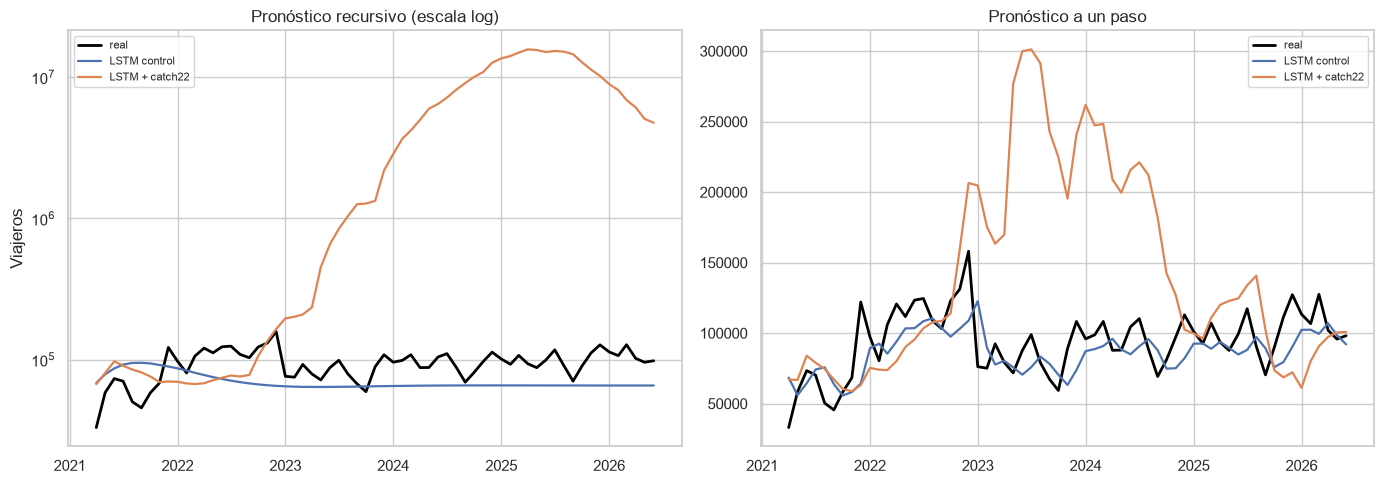

Ultimo mes pronosticado de forma recursiva (junio 2026):
  real                :       98,198 viajeros
  LSTM control        :       65,581
  LSTM + catch22      :    4,758,091


In [16]:
# Grafico: el control univariado contra el modelo con catch22, en escala logaritmica
# porque la divergencia del recursivo saca al segundo de cualquier escala lineal.
idx = pd.date_range("2021-04-01", periods=len(te_log), freq="MS")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(idx, np.exp(te_log), color="black", lw=2, label="real")
ax[0].plot(idx, np.exp(pred_ctrl_rec), lw=1.6, label="LSTM control")
ax[0].plot(idx, np.exp(pred_c22_rec), lw=1.6, label="LSTM + catch22")
ax[0].set_yscale("log"); ax[0].set_title("Pronóstico recursivo (escala log)")
ax[0].set_ylabel("Viajeros"); ax[0].legend(fontsize=8)

ax[1].plot(idx, np.exp(te_log), color="black", lw=2, label="real")
ax[1].plot(idx, np.exp(pred_ctrl_paso), lw=1.6, label="LSTM control")
ax[1].plot(idx, np.exp(pred_c22_paso), lw=1.6, label="LSTM + catch22")
ax[1].set_title("Pronóstico a un paso"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Ultimo mes pronosticado de forma recursiva (junio 2026):")
print(f"  real                : {np.exp(te_log[-1]):>12,.0f} viajeros")
print(f"  LSTM control        : {np.exp(pred_ctrl_rec[-1]):>12,.0f}")
print(f"  LSTM + catch22      : {np.exp(pred_c22_rec[-1]):>12,.0f}")
